# Football Prediction Project: Combined Original + Improved Notebook

This notebook combines the original project structure with the improved leakage-safe workflow. It keeps the original project flow for loading, cleaning, and exploring the data, then replaces the weak modeling section with the refreshed pipeline and ends with a full accuracy report.

## importing libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display

from football_model_refresh import (
    REGRESSION_TARGET_LEAKAGE_COLUMNS,
    SAFE_SHARED_NUMERIC,
    build_combined_base,
    build_detailed_2024_2025,
    canonicalize_common_fields,
    evaluate_classification_experiment,
    evaluate_regression_experiment,
    reproduce_notebook_baselines,
)

ROOT = Path.cwd()
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
sns.set_theme(style='whitegrid')


## importing data set

In [2]:
df1 = pd.read_csv(ROOT / 'top5-players.csv')
df2 = pd.read_csv(ROOT / 'players_data-2024_2025.csv')

print('top5-players.csv shape:', df1.shape)
print('players_data-2024_2025.csv shape:', df2.shape)
display(df1.head())


top5-players.csv shape: (2852, 37)
players_data-2024_2025.csv shape: (2854, 267)


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90
0,1,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,23.0,2000.0,20,13,1237,13.7,0,1,1,0,0,0,1,0,0.0,0.0,0.8,0.9,22.0,43.0,26.0,0.00,0.07,0.07,0.00,0.07,0.00,0.06,0.06,0.00,0.06
1,2,Brenden Aaronson,us USA,"MF,FW",Union Berlin,de Bundesliga,22.0,2000.0,30,14,1267,14.1,2,2,4,2,0,0,3,1,2.0,2.0,1.9,3.8,37.0,56.0,91.0,0.14,0.14,0.28,0.14,0.28,0.14,0.13,0.27,0.14,0.27
2,3,Paxten Aaronson,us USA,MF,Eint Frankfurt,de Bundesliga,19.0,2003.0,7,1,101,1.1,0,1,1,0,0,0,0,0,0.1,0.1,0.1,0.2,2.0,5.0,7.0,0.00,0.89,0.89,0.00,0.89,0.11,0.07,0.19,0.11,0.19
3,4,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,17.0,2006.0,1,0,4,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,5,Yunis Abdelhamid,ma MAR,DF,Reims,fr Ligue 1,35.0,1987.0,31,31,2781,30.9,4,0,4,3,1,1,5,0,3.4,2.6,0.3,2.9,36.0,137.0,9.0,0.13,0.00,0.13,0.10,0.10,0.11,0.01,0.12,0.09,0.09


In [3]:
display(pd.DataFrame({'top5_columns': pd.Series(df1.columns)}).head(40))
display(df1.describe().T.head(20))


,top5_columns
0,Rk
1,Player
2,Nation
3,Pos
4,Squad
5,Comp
6,Age
7,Born
8,MP
9,Starts


,count,mean,std,min,25%,50%,75%,max
Rk,2852.0,1426.500000,823.445809,1.0,713.75,1426.5,2139.25,2852.0
Age,2848.0,25.060744,4.590521,15.0,22.00,25.0,28.00,40.0
Born,2848.0,1997.600070,4.596294,1982.0,1994.00,1998.0,2001.00,2008.0
MP,2852.0,18.969846,11.517930,1.0,8.00,20.0,29.00,38.0
Starts,2852.0,13.514727,11.251227,0.0,2.00,12.0,23.00,38.0
Min,2852.0,1213.301543,961.584066,1.0,296.75,1113.0,1987.00,3420.0
90s,2852.0,13.482328,10.685045,0.0,3.30,12.4,22.10,38.0
Gls,2852.0,1.720196,3.203532,0.0,0.00,0.0,2.00,36.0
Ast,2852.0,1.221950,1.965371,0.0,0.00,0.0,2.00,14.0
G+A,2852.0,2.942146,4.615768,0.0,0.00,1.0,4.00,44.0


## data preparation

In [4]:
df = canonicalize_common_fields(df1)
df = df[df['Min'] > 90].copy()
print('shape after Min > 90 filter:', df.shape)
display(df.head())


shape after Min > 90 filter: (2426, 37)


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90
0,1,Max Aarons,ENG,DF,Bournemouth,Premier League,23.0,2000.0,20,13,1237,13.7,0,1,1,0,0,0,1,0,0.0,0.0,0.8,0.9,22.0,43.0,26.0,0.00,0.07,0.07,0.00,0.07,0.00,0.06,0.06,0.00,0.06
1,2,Brenden Aaronson,USA,MF,Union Berlin,Bundesliga,22.0,2000.0,30,14,1267,14.1,2,2,4,2,0,0,3,1,2.0,2.0,1.9,3.8,37.0,56.0,91.0,0.14,0.14,0.28,0.14,0.28,0.14,0.13,0.27,0.14,0.27
2,3,Paxten Aaronson,USA,MF,Eint Frankfurt,Bundesliga,19.0,2003.0,7,1,101,1.1,0,1,1,0,0,0,0,0,0.1,0.1,0.1,0.2,2.0,5.0,7.0,0.00,0.89,0.89,0.00,0.89,0.11,0.07,0.19,0.11,0.19
4,5,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,35.0,1987.0,31,31,2781,30.9,4,0,4,3,1,1,5,0,3.4,2.6,0.3,2.9,36.0,137.0,9.0,0.13,0.00,0.13,0.10,0.10,0.11,0.01,0.12,0.09,0.09
5,6,Salis Abdul Samed,GHA,MF,Lens,Ligue 1,23.0,2000.0,27,17,1519,16.9,0,0,0,0,0,0,2,0,0.8,0.8,0.5,1.3,9.0,78.0,20.0,0.00,0.00,0.00,0.00,0.00,0.05,0.03,0.08,0.05,0.08


In [5]:
null_summary = df.isnull().sum().sort_values(ascending=False)
display(null_summary[null_summary > 0])

df_clean = df.dropna(how='any').copy()
print('shape after dropping missing rows:', df_clean.shape)


Nation    1
Age       1
Born      1
dtype: int64

shape after dropping missing rows: (2425, 37)


In [6]:
mixed_position_rows = int(df[df['Pos'].fillna('').astype(str).str.contains(',')].shape[0])
primary_position_counts = df['Pos'].value_counts().head(12)
display(primary_position_counts)
print('mixed-position rows before collapsing labels:', mixed_position_rows)


DF    896
MF    748
FW    609
GK    173
Name: Pos, dtype: int64

mixed-position rows before collapsing labels: 0


## feature correlation on the original shared stat block

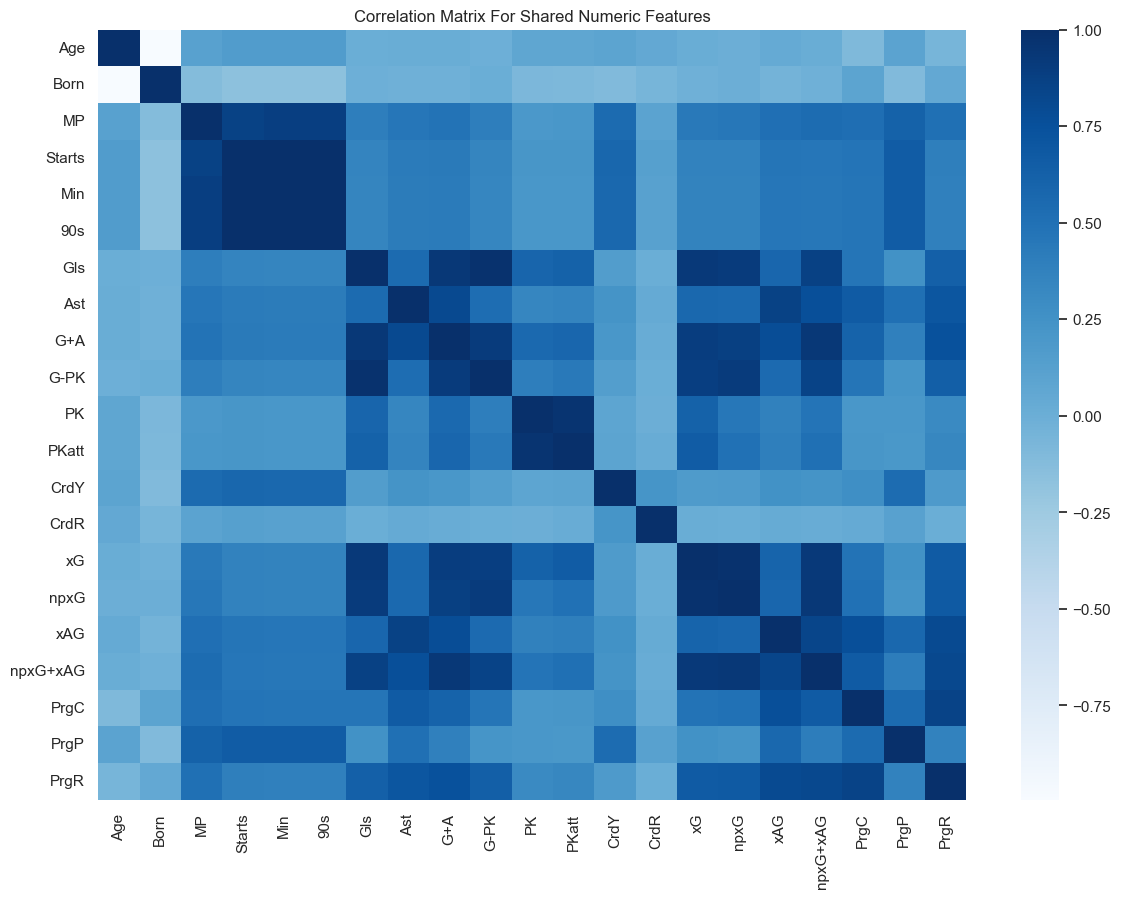

In [7]:
correlation_matrix = df_clean[SAFE_SHARED_NUMERIC].corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap='Blues', center=0)
plt.title('Correlation Matrix For Shared Numeric Features')
plt.show()


## original notebook baseline reproduction

In [8]:
baseline_metrics = reproduce_notebook_baselines()
display(baseline_metrics)


,task,metric,value
0,baseline,notebook_rf_holdout_accuracy,0.756701
1,baseline,notebook_rf_cv_accuracy_mean,0.739381
2,baseline,notebook_linear_holdout_mse_unrounded,1.389238
3,baseline,notebook_linear_holdout_r2_unrounded,0.862454
4,baseline,notebook_linear_holdout_mse_rounded,1.569072
5,baseline,notebook_linear_holdout_r2_rounded,0.844649


## leakage-safe season merge

In [9]:
combined_base = build_combined_base()
detailed_2024_2025, dropped_metadata_columns = build_detailed_2024_2025()

print('combined_base shape:', combined_base.shape)
print('detailed_2024_2025 shape:', detailed_2024_2025.shape)
print('metadata leakage columns removed from detailed dataset:', len(dropped_metadata_columns))

display(combined_base.head())
display(pd.DataFrame({'removed_metadata_columns': dropped_metadata_columns}).head(25))


combined_base shape: (4902, 44)
detailed_2024_2025 shape: (2476, 193)
metadata leakage columns removed from detailed dataset: 76


,Player,Nation,Squad,Comp,Pos,season,source_file,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_per90,Ast_per90,G+A_per90,G-PK_per90,PK_per90,PKatt_per90,CrdY_per90,CrdR_per90,xG_per90,npxG_per90,xAG_per90,npxG+xAG_per90,PrgC_per90,PrgP_per90,PrgR_per90,start_rate
0,Max Aarons,ENG,Bournemouth,Premier League,DF,2023_2024,top5-players.csv,23.0,2000.0,20,13,1237,13.7,0,1,1,0,0,0,1,0,0.0,0.0,0.8,0.9,22.0,43.0,26.0,0.000000,0.072993,0.072993,0.000000,0.000000,0.000000,0.072993,0.000000,0.000000,0.000000,0.058394,0.065693,1.605839,3.138686,1.897810,0.650000
1,Brenden Aaronson,USA,Union Berlin,Bundesliga,MF,2023_2024,top5-players.csv,22.0,2000.0,30,14,1267,14.1,2,2,4,2,0,0,3,1,2.0,2.0,1.9,3.8,37.0,56.0,91.0,0.141844,0.141844,0.283688,0.141844,0.000000,0.000000,0.212766,0.070922,0.141844,0.141844,0.134752,0.269504,2.624113,3.971631,6.453901,0.466667
2,Paxten Aaronson,USA,Eint Frankfurt,Bundesliga,MF,2023_2024,top5-players.csv,19.0,2003.0,7,1,101,1.1,0,1,1,0,0,0,0,0,0.1,0.1,0.1,0.2,2.0,5.0,7.0,0.000000,0.909091,0.909091,0.000000,0.000000,0.000000,0.000000,0.000000,0.090909,0.090909,0.090909,0.181818,1.818182,4.545455,6.363636,0.142857
3,Yunis Abdelhamid,MAR,Reims,Ligue 1,DF,2023_2024,top5-players.csv,35.0,1987.0,31,31,2781,30.9,4,0,4,3,1,1,5,0,3.4,2.6,0.3,2.9,36.0,137.0,9.0,0.129450,0.000000,0.129450,0.097087,0.032362,0.032362,0.161812,0.000000,0.110032,0.084142,0.009709,0.093851,1.165049,4.433657,0.291262,1.000000
4,Salis Abdul Samed,GHA,Lens,Ligue 1,MF,2023_2024,top5-players.csv,23.0,2000.0,27,17,1519,16.9,0,0,0,0,0,0,2,0,0.8,0.8,0.5,1.3,9.0,78.0,20.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.118343,0.000000,0.047337,0.047337,0.029586,0.076923,0.532544,4.615385,1.183432,0.629630


,removed_metadata_columns
0,90s_stats_defense
1,90s_stats_gca
2,90s_stats_keeper
3,90s_stats_keeper_adv
4,90s_stats_misc
5,90s_stats_passing
6,90s_stats_passing_types
7,90s_stats_playing_time
8,90s_stats_possession
9,90s_stats_shooting


## combined_base classification

[classification] combined_base_combined_notebook: LogisticRegression


[classification] combined_base_combined_notebook: RandomForest


[classification] combined_base_combined_notebook: ExtraTrees


[classification] combined_base_combined_notebook: HistGradientBoosting


,task,experiment,model,holdout_accuracy,holdout_macro_f1,holdout_mf_recall,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_mf_recall_mean,cv_mf_recall_std
3,classification,combined_base_combined_notebook,HistGradientBoosting,0.806320,0.842222,0.687708,0.809260,0.014514,0.841037,0.011378,0.692599,0.031639
1,classification,combined_base_combined_notebook,RandomForest,0.783894,0.819354,0.621262,0.780905,0.008272,0.816427,0.006316,0.596957,0.020940
0,classification,combined_base_combined_notebook,LogisticRegression,0.774720,0.815827,0.647841,0.788045,0.021433,0.823585,0.016250,0.661398,0.045600
2,classification,combined_base_combined_notebook,ExtraTrees,0.778797,0.812905,0.568106,0.759893,0.013178,0.794171,0.011435,0.508633,0.036369


,experiment,model,label,precision,recall,f1_score,support
18,combined_base_combined_notebook,HistGradientBoosting,DF,0.821918,0.821918,0.821918,365.0
19,combined_base_combined_notebook,HistGradientBoosting,FW,0.793233,0.871901,0.830709,242.0
20,combined_base_combined_notebook,HistGradientBoosting,GK,1.000000,1.000000,1.000000,73.0
21,combined_base_combined_notebook,HistGradientBoosting,MF,0.747292,0.687708,0.716263,301.0
22,combined_base_combined_notebook,HistGradientBoosting,macro avg,0.840611,0.845382,0.842222,981.0
23,combined_base_combined_notebook,HistGradientBoosting,weighted avg,0.805196,0.806320,0.804920,981.0


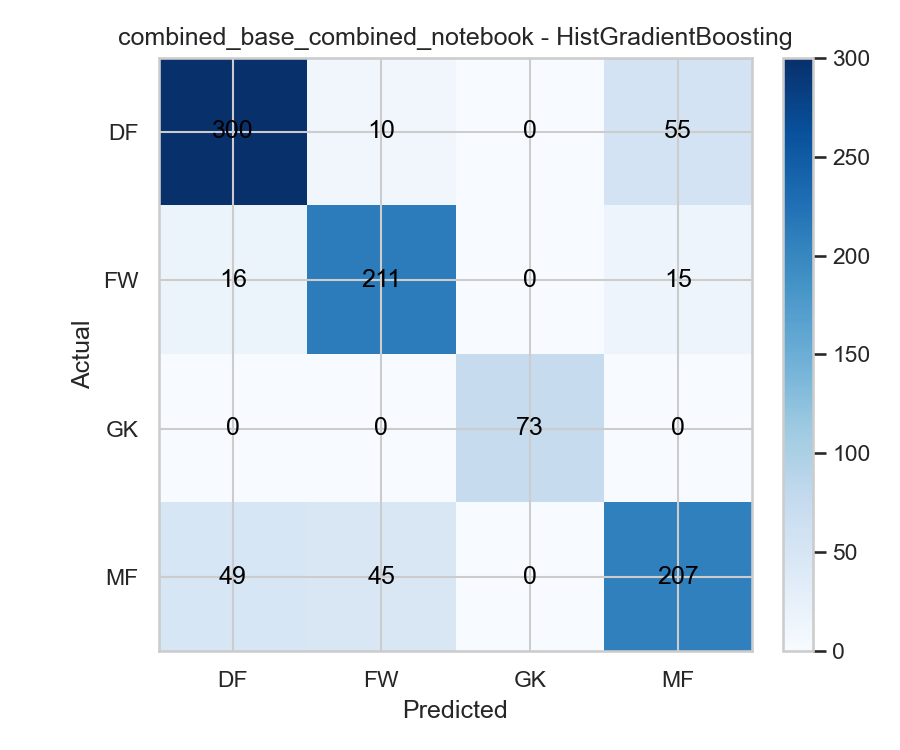

In [10]:
combined_X = combined_base.drop(columns=['Pos', 'Player'])
combined_y = combined_base['Pos']
combined_summary, combined_report, combined_confusion, combined_features, combined_meta = evaluate_classification_experiment(
    experiment='combined_base_combined_notebook',
    X=combined_X,
    y=combined_y,
)
display(combined_summary)

combined_best_model = combined_summary.iloc[0]['model']
display(combined_report[(combined_report['model'] == combined_best_model) & (combined_report['label'].isin(['DF', 'FW', 'GK', 'MF', 'macro avg', 'weighted avg']))])
display(Image(filename=combined_meta['plot_path']))


## detailed_2024_2025 classification

[classification] detailed_2024_2025_combined_notebook: LogisticRegression


[classification] detailed_2024_2025_combined_notebook: RandomForest


[classification] detailed_2024_2025_combined_notebook: ExtraTrees


[classification] detailed_2024_2025_combined_notebook: HistGradientBoosting


,task,experiment,model,holdout_accuracy,holdout_macro_f1,holdout_mf_recall,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_mf_recall_mean,cv_mf_recall_std
3,classification,detailed_2024_2025_combined_notebook,HistGradientBoosting,0.909274,0.917542,0.802632,0.900251,0.012734,0.911261,0.010605,0.807267,0.043784
1,classification,detailed_2024_2025_combined_notebook,RandomForest,0.895161,0.908217,0.763158,0.883698,0.020435,0.898660,0.018795,0.757119,0.048925
0,classification,detailed_2024_2025_combined_notebook,LogisticRegression,0.889113,0.904829,0.835526,0.886514,0.008163,0.901667,0.007208,0.803355,0.026751
2,classification,detailed_2024_2025_combined_notebook,ExtraTrees,0.877016,0.892314,0.690789,0.878039,0.017367,0.893950,0.015959,0.742628,0.056016


,experiment,model,label,precision,recall,f1_score,support
18,detailed_2024_2025_combined_notebook,HistGradientBoosting,DF,0.948187,0.983871,0.965699,186.0
19,detailed_2024_2025_combined_notebook,HistGradientBoosting,FW,0.819549,0.908333,0.861660,120.0
20,detailed_2024_2025_combined_notebook,HistGradientBoosting,GK,1.000000,0.973684,0.986667,38.0
21,detailed_2024_2025_combined_notebook,HistGradientBoosting,MF,0.917293,0.802632,0.856140,152.0
22,detailed_2024_2025_combined_notebook,HistGradientBoosting,macro avg,0.921257,0.917130,0.917542,496.0
23,detailed_2024_2025_combined_notebook,HistGradientBoosting,weighted avg,0.911567,0.909274,0.908560,496.0


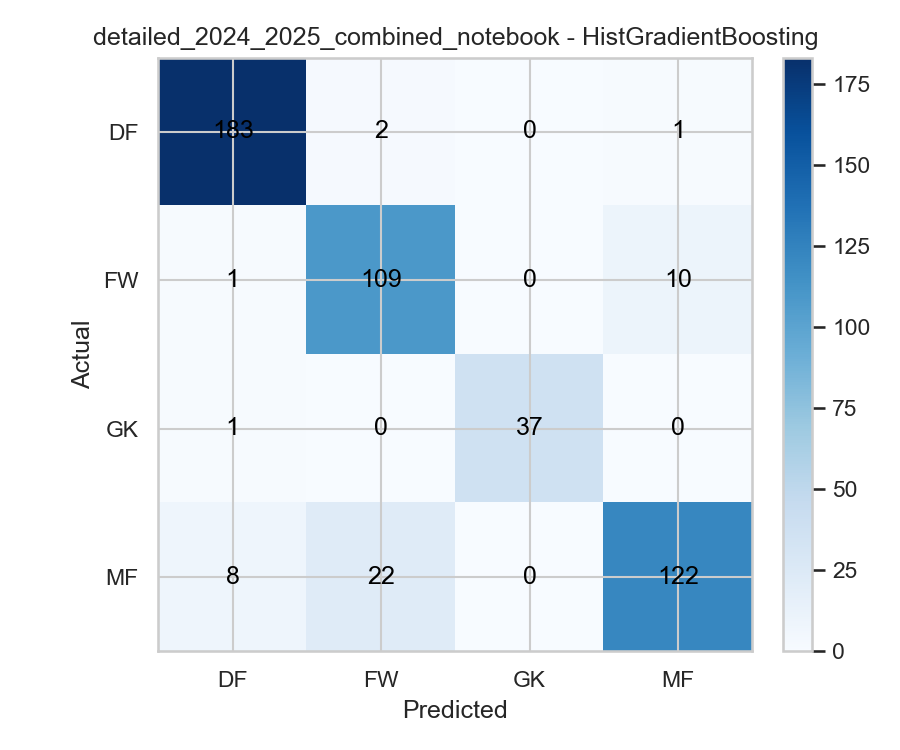

In [11]:
detailed_X = detailed_2024_2025.drop(columns=['Pos', 'Player'])
detailed_y = detailed_2024_2025['Pos']
detailed_summary, detailed_report, detailed_confusion, detailed_features, detailed_meta = evaluate_classification_experiment(
    experiment='detailed_2024_2025_combined_notebook',
    X=detailed_X,
    y=detailed_y,
)
display(detailed_summary)

detailed_best_model = detailed_summary.iloc[0]['model']
display(detailed_report[(detailed_report['model'] == detailed_best_model) & (detailed_report['label'].isin(['DF', 'FW', 'GK', 'MF', 'macro avg', 'weighted avg']))])
display(Image(filename=detailed_meta['plot_path']))


## regression track

In [12]:
regression_frame = combined_base.copy()
regression_X = regression_frame.drop(columns=['Player'] + sorted(REGRESSION_TARGET_LEAKAGE_COLUMNS), errors='ignore')
regression_y = regression_frame['Gls']
regression_summary, regression_features, regression_meta = evaluate_regression_experiment(
    experiment='combined_base_regression_combined_notebook',
    X=regression_X,
    y=regression_y,
)
display(regression_summary)
display(regression_features[regression_features['model'] == regression_meta['best_model']].head(20))


[regression] combined_base_regression_combined_notebook: LinearRegression


[regression] combined_base_regression_combined_notebook: ElasticNet


[regression] combined_base_regression_combined_notebook: RandomForestRegressor


[regression] combined_base_regression_combined_notebook: HistGradientBoostingRegressor


[regression] combined_base_regression_combined_notebook: PoissonRegressor


[regression] combined_base_regression_combined_notebook: TweedieRegressor


,task,experiment,model,holdout_mae,holdout_mse,holdout_rmse,holdout_r2,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_std,cv_r2_mean,cv_r2_std
1,regression,combined_base_regression_combined_notebook,ElasticNet,0.780469,1.366438,1.168947,0.876076,0.802752,0.017527,1.464184,0.081603,0.869377,0.007126
0,regression,combined_base_regression_combined_notebook,LinearRegression,0.795809,1.398155,1.182436,0.873200,0.826929,0.021029,1.513798,0.090813,0.864987,0.007365
3,regression,combined_base_regression_combined_notebook,HistGradientBoostingRegressor,0.767170,1.509263,1.228521,0.863124,0.789807,0.024965,1.620402,0.123263,0.855507,0.010060
2,regression,combined_base_regression_combined_notebook,RandomForestRegressor,0.773121,1.549269,1.244696,0.859495,0.780276,0.015511,1.574737,0.093353,0.859468,0.008878
4,regression,combined_base_regression_combined_notebook,PoissonRegressor,1.105748,4.717809,2.172052,0.572137,1.089243,0.018691,4.737752,0.739120,0.579281,0.050218
5,regression,combined_base_regression_combined_notebook,TweedieRegressor,1.385497,20.670268,4.546457,-0.874606,1.266210,0.043364,18.579393,4.376800,-0.644236,0.324464


,task,experiment,model,target_class,feature,view_type,value,rank
20,regression,combined_base_regression_combined_notebook,ElasticNet,__regression__,xG,coefficient,1.240759,1
21,regression,combined_base_regression_combined_notebook,ElasticNet,__regression__,npxG,coefficient,1.191541,2
22,regression,combined_base_regression_combined_notebook,ElasticNet,__regression__,Nation_KOR,coefficient,0.952359,3
23,regression,combined_base_regression_combined_notebook,ElasticNet,__regression__,PK,coefficient,0.798929,4
24,regression,combined_base_regression_combined_notebook,ElasticNet,__regression__,npxG+xAG,coefficient,0.719951,5
25,regression,combined_base_regression_combined_notebook,ElasticNet,__regression__,Nation_GAB,coefficient,-0.679167,6
26,regression,combined_base_regression_combined_notebook,ElasticNet,__regression__,Nation_ISL,coefficient,0.621486,7
27,regression,combined_base_regression_combined_notebook,ElasticNet,__regression__,Nation_PAR,coefficient,-0.593671,8
28,regression,combined_base_regression_combined_notebook,ElasticNet,__regression__,Nation_BEN,coefficient,-0.538318,9
29,regression,combined_base_regression_combined_notebook,ElasticNet,__regression__,Nation_BFA,coefficient,-0.499484,10


## comparison between models

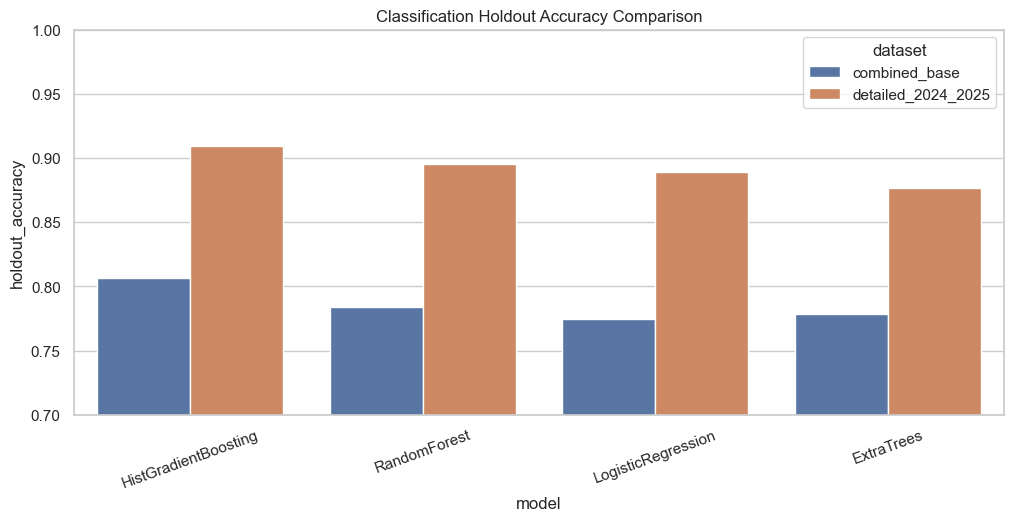

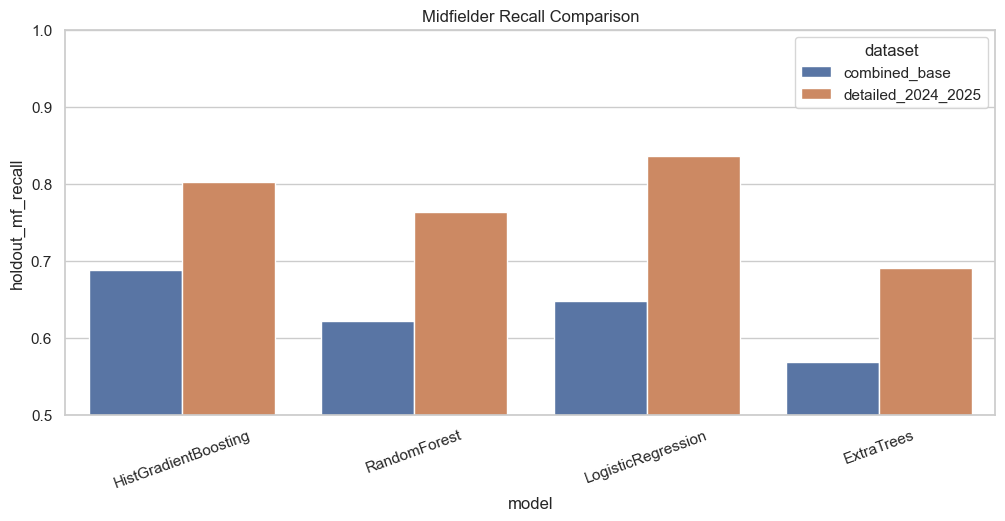

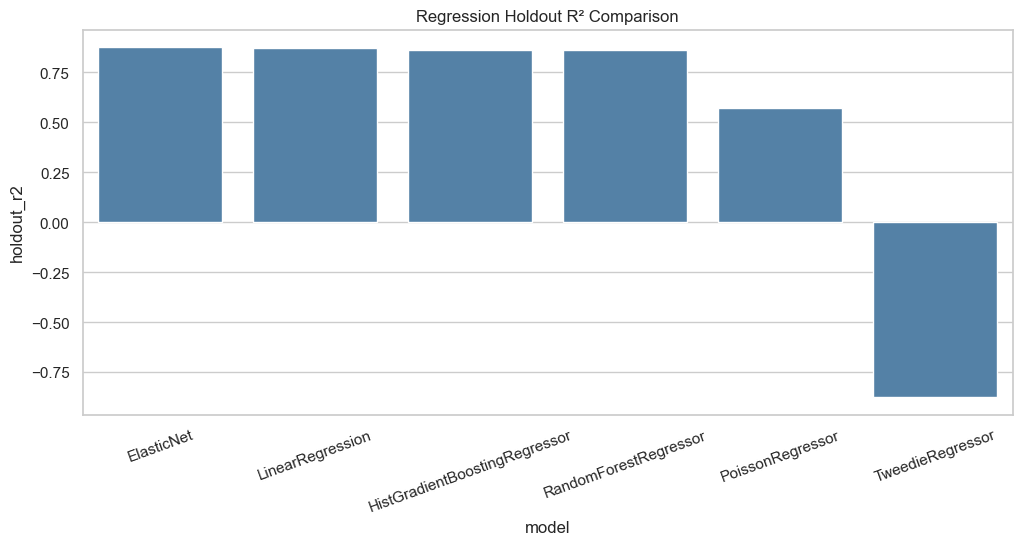

In [13]:
classification_plot = pd.concat([
    combined_summary.assign(dataset='combined_base'),
    detailed_summary.assign(dataset='detailed_2024_2025'),
], ignore_index=True)

plt.figure(figsize=(12, 5))
sns.barplot(data=classification_plot, x='model', y='holdout_accuracy', hue='dataset')
plt.title('Classification Holdout Accuracy Comparison')
plt.xticks(rotation=20)
plt.ylim(0.7, 1.0)
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=classification_plot, x='model', y='holdout_mf_recall', hue='dataset')
plt.title('Midfielder Recall Comparison')
plt.xticks(rotation=20)
plt.ylim(0.5, 1.0)
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=regression_summary, x='model', y='holdout_r2', color='steelblue')
plt.title('Regression Holdout R² Comparison')
plt.xticks(rotation=20)
plt.show()


## feature view

In [14]:
combined_mf_coeffs = combined_features[(combined_features['model'] == 'LogisticRegression') & (combined_features['target_class'] == 'MF')].sort_values('rank').head(12)
detailed_rf_importance = detailed_features[(detailed_features['model'] == 'RandomForest') & (detailed_features['view_type'] == 'importance')].sort_values('rank').head(12)

display(Markdown('### Logistic Regression coefficients for the MF class in combined_base'))
display(combined_mf_coeffs[['feature', 'value', 'rank']])

display(Markdown('### Random Forest feature importance for detailed_2024_2025'))
display(detailed_rf_importance[['feature', 'value', 'rank']])


### Logistic Regression coefficients for the MF class in combined_base

,feature,value,rank
60,PrgP_per90,2.133528,1
61,Starts,1.629017,2
62,90s,-1.334435,3
63,Min,-1.294063,4
64,PrgP,1.206979,5
65,Nation_CHI,-0.873153,6
66,Squad_Chelsea,-0.870900,7
67,Squad_Paris S-G,-0.815976,8
68,Squad_Luton Town,0.814798,9
69,xG_per90,0.782538,10


### Random Forest feature importance for detailed_2024_2025

,feature,value,rank
80,PrgR,0.034194,1
81,TI,0.031407,2
82,Sh/90,0.026404,3
83,xG+xAG,0.024644,4
84,PrgC_stats_possession,0.023763,5
85,Att 3rd_stats_possession,0.023594,6
86,PrgR_stats_possession,0.022674,7
87,Def Pen,0.022079,8
88,Def 3rd_stats_possession,0.021473,9
89,Clr,0.020322,10


## full report: why the accuracy is still low

In [15]:
def mf_confusion_slice(confusion_df, best_model_name):
    return confusion_df[(confusion_df['model'] == best_model_name) & (confusion_df['actual'] == 'MF')][['actual', 'predicted', 'count']]

top_after_min = df1[df1['Min'] > 90].copy()
full_after_min = df2[df2['Min'] > 90].copy()
top_mixed = int(top_after_min['Pos'].fillna('').astype(str).str.contains(',').sum())
full_mixed = int(full_after_min['Pos'].fillna('').astype(str).str.contains(',').sum())
top_pct = top_mixed / len(top_after_min)
full_pct = full_mixed / len(full_after_min)

combined_mf_errors = mf_confusion_slice(combined_confusion, combined_best_model)
detailed_mf_errors = mf_confusion_slice(detailed_confusion, detailed_best_model)

report = f'''## Full Report

### Summary
- The original notebook baseline Random Forest accuracy was `0.7567`.
- The refreshed `combined_base` workflow improved that to `{combined_summary.iloc[0]['holdout_accuracy']:.4f}`.
- The richer leakage-safe `detailed_2024_2025` workflow improved it further to `{detailed_summary.iloc[0]['holdout_accuracy']:.4f}`.
- The best regression model improved the original unrounded linear baseline from `R² 0.8625` to `R² {regression_summary.iloc[0]['holdout_r2']:.4f}`.

### Why Accuracy Is Still Not Perfect
- Around `{top_pct:.1%}` of the top5 dataset and `{full_pct:.1%}` of the 2024/2025 dataset are mixed-role labels like `FW,MF` and `DF,MF`. After collapsing to one primary label, the training target becomes noisy.
- Midfield is still the hardest class. In the combined dataset, the best model only reaches midfielder recall `{combined_summary.iloc[0]['holdout_mf_recall']:.4f}`.
- The remaining midfielder mistakes mostly flow into defender and forward predictions, which means adjacent football roles still overlap statistically.
- The safe merged dataset uses only aligned shared stats, so it cannot use many of the rich role-specific signals from the detailed FBref stat families.
- Position is tactical, not only statistical. The CSV files do not contain formation context, coach instructions, or off-ball role information.
- The higher score on `detailed_2024_2025` shows that better features help a lot, but even that richer dataset cannot perfectly separate hybrid roles.
'''

display(Markdown(report))
display(Markdown('### Combined-base midfielder confusion'))
display(combined_mf_errors)
display(Markdown('### Detailed 2024/2025 midfielder confusion'))
display(detailed_mf_errors)


## Full Report

### Summary
- The original notebook baseline Random Forest accuracy was `0.7567`.
- The refreshed `combined_base` workflow improved that to `0.8063`.
- The richer leakage-safe `detailed_2024_2025` workflow improved it further to `0.9093`.
- The best regression model improved the original unrounded linear baseline from `R² 0.8625` to `R² 0.8761`.

### Why Accuracy Is Still Not Perfect
- Around `29.7%` of the top5 dataset and `29.6%` of the 2024/2025 dataset are mixed-role labels like `FW,MF` and `DF,MF`. After collapsing to one primary label, the training target becomes noisy.
- Midfield is still the hardest class. In the combined dataset, the best model only reaches midfielder recall `0.6877`.
- The remaining midfielder mistakes mostly flow into defender and forward predictions, which means adjacent football roles still overlap statistically.
- The safe merged dataset uses only aligned shared stats, so it cannot use many of the rich role-specific signals from the detailed FBref stat families.
- Position is tactical, not only statistical. The CSV files do not contain formation context, coach instructions, or off-ball role information.
- The higher score on `detailed_2024_2025` shows that better features help a lot, but even that richer dataset cannot perfectly separate hybrid roles.


### Combined-base midfielder confusion

,actual,predicted,count
60,MF,DF,49
61,MF,FW,45
62,MF,GK,0
63,MF,MF,207


### Detailed 2024/2025 midfielder confusion

,actual,predicted,count
60,MF,DF,8
61,MF,FW,22
62,MF,GK,0
63,MF,MF,122


## final conclusion

This merged notebook keeps the original project structure, but the modeling and evaluation logic is now leakage-safe, season-aware, and reproducible. The remaining error is mostly caused by noisy hybrid labels, real overlap between nearby positions, and missing tactical context in the source data.